# Anchoring in the open field

The trial-based classifier needs repeated traversals of the same track. An open-field
session has no trials, and any time window samples a different, partial subset of the
arena — so correlating one window against another confounds *did the code drift* with
*did the animal go somewhere else*. That confound does not exist on the linear track,
where every trial covers the same bins by construction.

**The fix**: score each window against a **whole-session reference map**, over the bins
that window actually visited. The reference has full coverage, so each comparison is
limited only by the window's own occupancy rather than by the intersection of two partial
maps. This is also the true analogue of the trial version, where each trial is scored by
its mean correlation with all the others — that is, with the consensus.

Everything downstream is unchanged: 2-means on the resulting score, higher cluster
anchored, then the size-5 median filter.

**Ground truth.** The recurrent network provides it. A 30-minute 2D random walk is run
through the network with the position cue present (hidden state re-anchored to true
position every second), then absent (state integrates velocity blind and drifts), then
restored. That gives a true per-window label the classifier never sees.

In [1]:
import sys, os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import pynapple as nap
from matplotlib.collections import LineCollection
from spatial_manifolds.anchoring import (open_field_anchoring, labels_to_samples,
                                         occupancy_ratemap, ANCH_COLOR, NONANCH_COLOR)
plt.rcParams['font.family'] = 'Arial'

SIM = '/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/net7_2D_OF_sim/of_switch.npz'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
SOURCE_PATH = '/Users/harryclark/Downloads/clark2025/'

_z = np.load(SIM, allow_pickle=True)
ACTS, POS, PHASE = _z['acts'], _z['pos'], _z['phase'].astype(str)
GRID_SCORES, BOX_W = _z['grid_scores'], float(_z['box_width'])
DT = 0.02
WINDOW = 3000                     # samples = 60 s at 50 Hz
N_BINS = 12

print(f'simulation: {len(POS)} samples ({len(POS)*DT/60:.0f} min), {ACTS.shape[1]} units, '
      f'{BOX_W*100:.0f} cm box')
print(f'phases: A {int((PHASE=="A").sum())} samples, C {int((PHASE=="C").sum())} samples')
print(f'window {WINDOW} samples = {WINDOW*DT:.0f} s')

simulation: 90000 samples (30 min), 1024 units, 220 cm box
phases: A 60000 samples, C 30000 samples
window 3000 samples = 60 s


## Validation against the network's ground truth

Window length is the one free parameter, and coverage sets its floor: a 30 s window
visits ~72% of bins, 60 s ~93%. Too short and windows are too sparse to correlate; too
long and state changes are smeared across window boundaries.

In [2]:
def truth_for(window):
    st = np.arange(0, len(POS) - window + 1, window)
    return st, np.array([1 if (PHASE[s:s+window] == 'A').mean() > 0.5 else 0 for s in st])

gc_units = np.where(GRID_SCORES > 0.3)[0][:100]
ng_units = np.where(GRID_SCORES < 0.0)[0][:100]

rows = []
for W in (1500, 3000, 4500, 9000):
    st, truth = truth_for(W)
    for label, units in (('grid', gc_units), ('non-grid', ng_units)):
        acc = []
        for u in units:
            lab, _, _ = open_field_anchoring(ACTS[:, u], POS, W, n_bins=N_BINS, box_width=BOX_W)
            if np.isnan(lab).all():
                continue
            acc.append(np.nanmean(lab == truth))
        rows.append(dict(window_s=W*DT, units=label, n=len(acc),
                         median_accuracy=round(float(np.median(acc)), 3),
                         frac_above_0p9=round(float(np.mean(np.array(acc) > 0.9)), 2)))
val = pd.DataFrame(rows)
print(val.to_string(index=False))
print('\nNon-grid units are included deliberately: the classifier asks about '
      'self-consistency, not periodicity, so it should not be grid-specific.')

 window_s    units   n  median_accuracy  frac_above_0p9
     30.0     grid 100              1.0            1.00
     30.0 non-grid 100              1.0            1.00
     60.0     grid 100              1.0            1.00
     60.0 non-grid 100              1.0            1.00
     90.0     grid 100              1.0            1.00
     90.0 non-grid 100              1.0            1.00
    180.0     grid 100              0.6            0.06
    180.0 non-grid 100              0.6            0.01

Non-grid units are included deliberately: the classifier asks about self-consistency, not periodicity, so it should not be grid-specific.


## Example — a network grid unit

The trajectory is coloured by the classifier's per-window verdict. Because the cue-loss
phase is known, the true phase boundaries can be drawn on the time course beneath for
comparison — on real data there is nothing to compare against, which is the point of
validating here first.

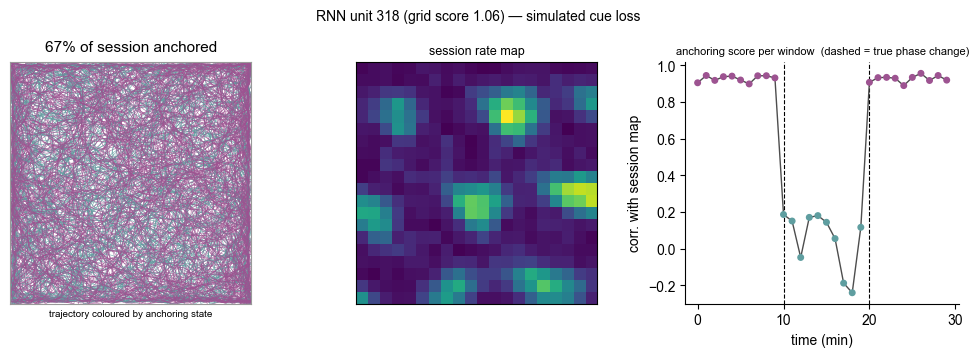

accuracy against ground truth: 1.000


In [3]:
def plot_anchoring_trajectory(activity, pos, window, box_w, title, truth=None,
                              n_bins=N_BINS, dt=DT, savepath=None):
    """Trajectory coloured by anchoring state, with the anchored percentage above."""
    lab, sc, st = open_field_anchoring(activity, pos, window, n_bins=n_bins, box_width=box_w)
    per_sample = labels_to_samples(lab, st, window, len(pos))
    pct = 100 * np.nanmean(lab)

    fig = plt.figure(figsize=(10, 3.6))
    ax0 = fig.add_subplot(1, 3, 1)
    ax1 = fig.add_subplot(1, 3, 2)
    ax2 = fig.add_subplot(1, 3, 3)

    # trajectory, coloured per sample by the window's verdict
    seg = np.stack([pos[:-1], pos[1:]], axis=1)
    col = np.where(np.isnan(per_sample[:-1]), np.nan, per_sample[:-1])
    cols = np.array([ANCH_COLOR if c == 1 else (NONANCH_COLOR if c == 0 else '#ffffff00')
                     for c in col])
    ax0.add_collection(LineCollection(seg, colors=cols, linewidths=0.45, alpha=0.85))
    hw = box_w / 2
    ax0.set_xlim(-hw, hw); ax0.set_ylim(-hw, hw); ax0.set_aspect('equal')
    ax0.set_xticks([]); ax0.set_yticks([])
    for sp in ax0.spines.values():
        sp.set_color('0.6')
    ax0.set_title(f'{pct:.0f}% of session anchored', fontsize=11, pad=8)
    ax0.set_xlabel('trajectory coloured by anchoring state', fontsize=7)

    # session rate map, for context
    rm = occupancy_ratemap(activity, pos, 20, box_w)
    cmap = plt.get_cmap('viridis').copy(); cmap.set_bad('0.9')
    ax1.imshow(np.ma.masked_invalid(rm.T), origin='lower', cmap=cmap)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title('session rate map', fontsize=9)

    # score time course
    t = st * dt / 60
    ax2.plot(t, sc, color='0.3', lw=1, zorder=2)
    ax2.scatter(t, sc, s=16, zorder=3,
                c=[ANCH_COLOR if l == 1 else NONANCH_COLOR for l in np.nan_to_num(lab)])
    if truth is not None:
        for b in np.where(np.diff(truth) != 0)[0]:
            ax2.axvline(t[b + 1], color='k', ls='--', lw=0.8, zorder=1)
    ax2.set_xlabel('time (min)'); ax2.set_ylabel('corr. with session map')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.set_title('anchoring score per window' +
                  ('  (dashed = true phase change)' if truth is not None else ''), fontsize=8)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches='tight')
    plt.show()
    return lab, sc, st


_st, _truth = truth_for(WINDOW)
_u = int(np.argsort(GRID_SCORES)[::-1][0])
_lab, _, _ = plot_anchoring_trajectory(
    ACTS[:, _u], POS, WINDOW, BOX_W,
    f'RNN unit {_u} (grid score {GRID_SCORES[_u]:.2f}) — simulated cue loss',
    truth=_truth, savepath=os.path.join(FIGPATH, 'of_anchoring_rnn_example.pdf'))
print(f'accuracy against ground truth: {np.nanmean(_lab == _truth):.3f}')

## Example — a recorded grid cell

The same classifier, unchanged, applied to a real open-field session. There is no ground
truth here: the score time course and the trajectory colouring are the output, and the
validation above is what licenses reading them.

M25 D25 OF1: 58 grid cells; using cluster 19 (grid score 1.34)
8718 samples at 10 Hz = 14.5 min of movement -> 14 windows of 60 s
mean rate 5.39 Hz


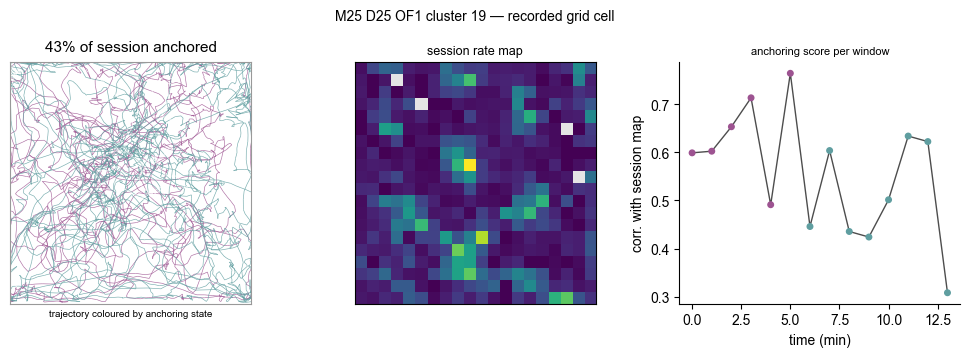

(array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.59901338, 0.60240974, 0.65325305, 0.71341879, 0.49115998,
        0.76436496, 0.44583385, 0.60377658, 0.43551344, 0.4239737 ,
        0.50143586, 0.63389634, 0.62242324, 0.30813063]),
 array([   0,  600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000,
        6600, 7200, 7800]))

In [4]:
MOUSE, DAY, SESSION = 25, 25, 'OF1'
_d = f'{SOURCE_PATH}M{MOUSE}/D{DAY}/{SESSION}/'
_stem = f'sub-M{MOUSE}_ses-D{DAY}_typ-{SESSION}'
beh = nap.load_file(_d + _stem + '_beh.nwb')
clusters = nap.load_file(_d + _stem + '_srt-kilosort4_clusters.npz')

cls = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_v2.csv')
sess_gc = cls[(cls.mouse == MOUSE) & (cls.day == DAY) & (cls.cell_class_of1 == 'GC')]
CELL = int(sess_gc.sort_values('grid_score_of1', ascending=False).iloc[0].cluster_id)
print(f'M{MOUSE} D{DAY} {SESSION}: {len(sess_gc)} grid cells; using cluster {CELL} '
      f'(grid score {sess_gc.grid_score_of1.max():.2f})')

# Position tracking is ~16 Hz here, so bin at 100 ms: coarse enough that every bin
# contains at least one tracking sample (no gaps to drop, so the sample index stays
# proportional to time and a window of N samples really is N x BIN seconds).
BIN_REAL = 0.1
BOX_REAL = 100.0                   # clark2025 open-field arena, coordinates 0-100 cm
_ep = beh['moving']
_px = np.asarray(beh['P_x'].bin_average(BIN_REAL, ep=_ep).values, float)
_py = np.asarray(beh['P_y'].bin_average(BIN_REAL, ep=_ep).values, float)
_act = np.asarray(clusters[CELL].count(BIN_REAL, ep=_ep).values, float) / BIN_REAL   # Hz

# interpolate the few missing tracking samples rather than dropping them, which
# would break the correspondence between sample index and elapsed time
_s = pd.DataFrame(dict(x=_px, y=_py, a=_act)).interpolate(limit_direction='both')
_pos = np.stack([_s.x.values, _s.y.values], axis=1) - BOX_REAL / 2
_act = np.nan_to_num(_s.a.values)

W_REAL = int(60 / BIN_REAL)        # 60 s, the window validated above
print(f'{len(_pos)} samples at {1/BIN_REAL:.0f} Hz = {len(_pos)*BIN_REAL/60:.1f} min of movement '
      f'-> {len(_pos)//W_REAL} windows of {W_REAL*BIN_REAL:.0f} s')
print(f'mean rate {_act.mean():.2f} Hz')

plot_anchoring_trajectory(_act, _pos, W_REAL, BOX_REAL,
                          f'M{MOUSE} D{DAY} {SESSION} cluster {CELL} — recorded grid cell',
                          truth=None, dt=BIN_REAL,
                          savepath=os.path.join(FIGPATH, 'of_anchoring_real_example.pdf'))